## <center> **Design matrices**
    
We will go through the examples from the previous StatQuest [6] design matrices for linear models ...

### t-test in regression

In StatQuest [6] we were interested in determing if there was a statistically significant difference between the size of control mice versus the size of mutant mice given that we measured their weights.

We ended with this equation:
$$ \text{y} = \text{control intercept} + \text{mutant offset} + \text{slope} $$
This equation fit two lines to the data one for the control mice and one for the mutant mice.

Now let´s see how we can test our hypothesis that there is no difference between control mice and mutant mice...

In [1]:
# get the data
import numpy as np
import pandas as pd

dict_ = {"Weight": [2.4, 3.5, 4.4, 4.9, 1.7, 2.8, 3.2, 3.9],
         
         "Size": [1.9, 3.0, 2.9, 3.7, 2.8, 3.3, 3.9, 4.8],
         
         "Type": ["control", "control", "control", "control",
                  "mutant", "mutant", "mutant", "mutant"]
        }

df = pd.DataFrame(dict_)
df

,Weight,Size,Type
0,2.4,1.9,control
1,3.5,3.0,control
2,4.4,2.9,control
3,4.9,3.7,control
4,1.7,2.8,mutant
5,2.8,3.3,mutant
6,3.2,3.9,mutant
7,3.9,4.8,mutant


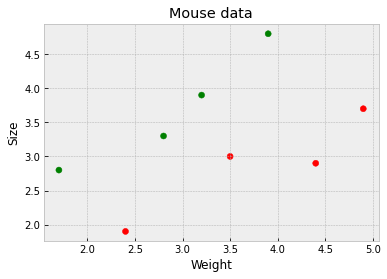

In [2]:
# plot the data
import matplotlib.pyplot as plt

switch_variable = np.where(df.Type == "control", 0, 1)
colormap = np.array(['r', 'g'])

plt.style.use('bmh')
plt.scatter(df.Weight, df.Size, color=colormap[switch_variable])
plt.xlabel("Weight"); plt.ylabel("Size"); plt.title("Mouse data")
plt.show()

In [3]:
# build the DESIGN MATRIX !
import statsmodels.api as sm

y = df.Size.values
X = sm.add_constant(np.column_stack((switch_variable, df.Weight))) 
print(X)

[[1.  0.  2.4]
 [1.  0.  3.5]
 [1.  0.  4.4]
 [1.  0.  4.9]
 [1.  1.  1.7]
 [1.  1.  2.8]
 [1.  1.  3.2]
 [1.  1.  3.9]]


`X` is the design matrix for our model ...

... the 1st column will be multiplied by the control intercept (in this case the control intercept will be on for all the measurements).

... the 2nd column will be multiplied by the mutant offset (in this case only the mutant values will turn the mutant offset on).

... the 3rd column will be multiplied by the slope.

In [4]:
# train LINEAR MODEL
lm = sm.OLS(y, X)
lines = lm.fit()

print(lines.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     21.88
Date:                Fri, 14 Jul 2023   Prob (F-statistic):            0.00337
Time:                        23:20:20   Log-Likelihood:               -0.54064
No. Observations:                   8   AIC:                             7.081
Df Residuals:                       5   BIC:                             7.320
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0805      0.527      0.153      0.8

C:\Users\Usuario\anaconda3\lib\site-packages\scipy\stats\stats.py:1603: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


So this is our fancy equation...
$$\text{y}=\text{control intercept}+\text{mutant offset}+\text{slope}$$

From the summary we observe the following:

- The p-value for the **F-statistic** (0,000337) compares the fit of our fancy equation to the simplest equation possible:
$$\text{y}=\text{overall mean}$$

- The p-value for the **weight parameter x2** (0,003) tells you how much better the fancy equation fits the data than if we had removed the weight parameter. This amounts to comparing the fit of the fancy equation to just a normal t-test:
$$\text{y}=\text{control intercept}+\text{mutant offset}$$

- The p-value for the **type of mouse x1** (0,002) tells us how much better the fancy equation fits the data than if we had removed the type of mouse information from the equation. This amounts to comparing the fit of the fancy equation to just a simple linear regression:
$$\text{y}=\text{control intercept}+\text{slope}$$

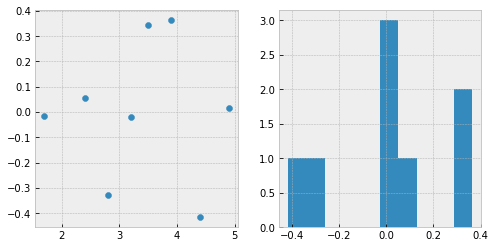

In [5]:
# check for normality in residuals
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].scatter(df.Weight, lines.resid)
axs[1].hist(lines.resid);

### Batch effect
In the second example we compared experiments done by two different labs.

There was a batch effect and we wanted to control for that...

In [6]:
# get the data
import numpy as np
import pandas as pd

dict_ = {"geneExp": [1.7, 2.0, 2.2,
                     3.1, 3.6, 3.9,
                     0.9, 1.2, 1.9,
                     1.8, 2.2, 2.9],
         
         "Lab": ["A", "A", "A", "A", "A", "A",
                 "B", "B", "B", "B", "B", "B"],
         
         "Type": ["control", "control", "control",
                  "mutant", "mutant", "mutant",
                  "control", "control", "control",
                  "mutant", "mutant", "mutant"]
        }

df = pd.DataFrame(dict_)
df

,geneExp,Lab,Type
0,1.7,A,control
1,2.0,A,control
2,2.2,A,control
3,3.1,A,mutant
4,3.6,A,mutant
5,3.9,A,mutant
6,0.9,B,control
7,1.2,B,control
8,1.9,B,control
9,1.8,B,mutant


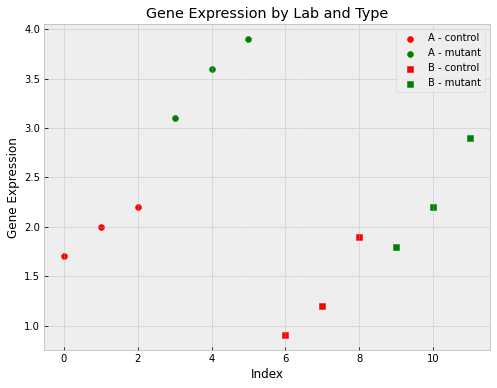

In [7]:
# plot the data
plt.figure(figsize=(8, 6))
colors = {'control': 'red', 'mutant': 'green'}
markers = {'A': 'o', 'B': 's'}

for lab, lab_df in df.groupby('Lab'):
    for typ, typ_df in lab_df.groupby('Type'):
        plt.scatter(typ_df.index, typ_df['geneExp'],
                    color=colors[typ], marker=markers[lab], label=f'{lab} - {typ}')

plt.xlabel('Index'); plt.ylabel('Gene Expression')
plt.title('Gene Expression by Lab and Type')
plt.legend()
plt.show()

In [8]:
# build the DESIGN MATRIX !
import statsmodels.api as sm

switch_variable1 = np.where(df.Lab == "A", 0, 1)
switch_variable2 = np.where(df.Type == "control", 0, 1)

y = df.geneExp.values
X = sm.add_constant(np.column_stack((switch_variable1, switch_variable2))) 
print(X)

[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 1.]
 [1. 0. 1.]
 [1. 0. 1.]
 [1. 1. 0.]
 [1. 1. 0.]
 [1. 1. 0.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


`X` is the design matrix for our model ...

... the 1st column will be multiplied by the term for the lab A control mean (this means that this value is on for every single measurement in the dataset).

... the 2nd column will be multiplied by the lab B offset (that means that this offset is only on for the data generated by lab B).

... the 3rd column will be multiplied by the term for the difference between the mean of the mutant data in the mean of the control data.

In [9]:
# train LINEAR MODEL
lm = sm.OLS(y, X)
batch_test = lm.fit()

print(batch_test.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.799
Model:                            OLS   Adj. R-squared:                  0.754
Method:                 Least Squares   F-statistic:                     17.87
Date:                Fri, 14 Jul 2023   Prob (F-statistic):           0.000734
Time:                        23:29:39   Log-Likelihood:                -5.8735
No. Observations:                  12   AIC:                             17.75
Df Residuals:                       9   BIC:                             19.20
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1167      0.228      9.287      0.0

C:\Users\Usuario\anaconda3\lib\site-packages\scipy\stats\stats.py:1603: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=12
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


So this is our fancy equation...
$$\text{y}=\text{lab A control mean}+\text{lab B offset}+\text{diff(mutant; control)}$$

We are testing wheter or not we can substract the term for the different types of mice from our fancy equation and still get a good fit...

The p-value for the **F-statistic** (0,000734) represents how much better our fancy equation fits the data to the following equation that is far too simple: $\text{y}=\text{overall mean}$. 
But this is not what we want!

The p-value for the **mouse type x2** (0,001) compares the fit of our fancy equation to this equation:
$\text{y}=\text{lab A control mean}+\text{lab B offset}$.
So this p-value is what we really want!

The **moral** of the story is that the p-value for the F-statistic is not always what we want; it reflects the comparison of your fancy equation to the simplest equation possible. IF that is not what you want then you are going to have to look around at the other p-values to find the one you need.

---